## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load dataset

In [2]:
df = pd.read_csv(r"C:\Users\zabiz\Downloads\crude-oil-price\Middle_East_Economic_Data_1990_2024_with_Oil.csv")

In [3]:
df

,Country,Country_Code,Year,Exports_pct_GDP,FDI_net_inflows_pct_GDP,GDP_current_USD,GDP_growth_annual_pct,GDP_per_capita_current_USD,Imports_pct_GDP,Inflation_consumer_prices_annual_pct,Life_expectancy_years,Unemployment_total_pct,Brent_Oil_Price_USD_per_barrel
0,Bahrain,BHR,1990,101.627082,1.907789,4.809511e+09,4.437997,9342.538914,83.201723,0.929335,72.587,NaN,23.0
1,Bahrain,BHR,1991,74.757141,11.800826,5.248911e+09,11.229998,10434.132396,84.110656,0.764420,72.668,1.047,20.0
2,Bahrain,BHR,1992,74.210844,16.078853,5.402232e+09,6.689998,10460.158322,85.081054,-0.172414,72.785,0.968,18.0
3,Bahrain,BHR,1993,73.764609,-4.650769,5.913001e+09,12.870007,11151.871496,70.998436,2.538860,72.939,0.882,19.0
4,Bahrain,BHR,1994,71.406483,3.289479,6.330628e+09,-0.250001,11629.359522,65.066988,0.816911,73.134,1.007,25.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
450,Yemen,YEM,2020,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.435,17.963,45.0
451,Yemen,YEM,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66.019,18.312,70.0
452,Yemen,YEM,2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,67.952,17.224,75.0
453,Yemen,YEM,2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.295,16.944,80.0


## Check null values

In [4]:
df.isnull().sum()

Country                                  0
Country_Code                             0
Year                                     0
Exports_pct_GDP                         26
FDI_net_inflows_pct_GDP                  9
GDP_current_USD                          7
GDP_growth_annual_pct                    8
GDP_per_capita_current_USD               7
Imports_pct_GDP                         26
Inflation_consumer_prices_annual_pct    60
Life_expectancy_years                   13
Unemployment_total_pct                  14
Brent_Oil_Price_USD_per_barrel           0
dtype: int64

# Check Null Values Through Plot Bar

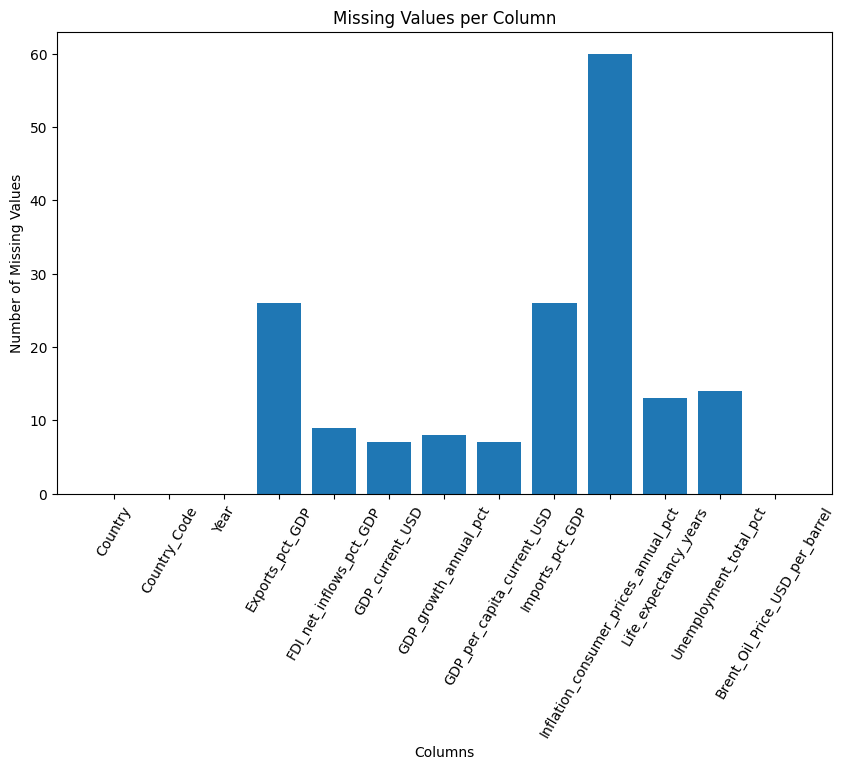

In [5]:
null_counts = df.isnull().sum()

plt.figure(figsize=(10,6))
plt.bar(null_counts.index, null_counts.values)

plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=60)
plt.show()

## Check the first 5 values

In [6]:
print(df.head())

   Country Country_Code  Year  Exports_pct_GDP  FDI_net_inflows_pct_GDP  \
0  Bahrain          BHR  1990       101.627082                 1.907789   
1  Bahrain          BHR  1991        74.757141                11.800826   
2  Bahrain          BHR  1992        74.210844                16.078853   
3  Bahrain          BHR  1993        73.764609                -4.650769   
4  Bahrain          BHR  1994        71.406483                 3.289479   

   GDP_current_USD  GDP_growth_annual_pct  GDP_per_capita_current_USD  \
0     4.809511e+09               4.437997                 9342.538914   
1     5.248911e+09              11.229998                10434.132396   
2     5.402232e+09               6.689998                10460.158322   
3     5.913001e+09              12.870007                11151.871496   
4     6.330628e+09              -0.250001                11629.359522   

   Imports_pct_GDP  Inflation_consumer_prices_annual_pct  \
0        83.201723                              0.

## Check the Statistical View

In [7]:
print(df.describe())

              Year  Exports_pct_GDP  FDI_net_inflows_pct_GDP  GDP_current_USD  \
count   455.000000       429.000000               446.000000     4.480000e+02   
mean   2007.000000        43.284590                 2.424305     1.493333e+11   
std      10.110622        22.148016                 3.756520     1.935098e+11   
min    1990.000000         0.005377                -4.650769     4.077963e+08   
25%    1998.000000        26.543532                 0.225459     2.303371e+10   
50%    2007.000000        39.663537                 1.209909     7.796705e+10   
75%    2016.000000        56.816544                 3.746649     1.869296e+11   
max    2024.000000       106.846139                29.520073     1.239805e+12   

       GDP_growth_annual_pct  GDP_per_capita_current_USD  Imports_pct_GDP  \
count             447.000000                  448.000000       429.000000   
mean                4.443106                17314.890293        40.990542   
std                 9.189132           

## Average Oil Price Trend

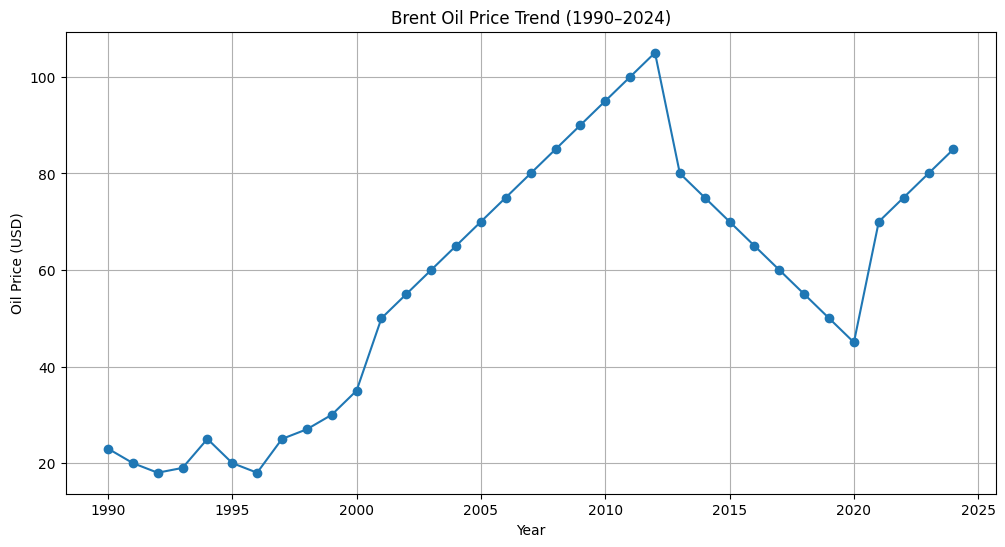

In [8]:
oil_year = df.groupby("Year")["Brent_Oil_Price_USD_per_barrel"].mean()

plt.figure(figsize=(12,6))
plt.plot(oil_year.index, oil_year.values, marker="o")
plt.title("Brent Oil Price Trend (1990–2024)")
plt.xlabel("Year")
plt.ylabel("Oil Price (USD)")
plt.grid(True)
plt.show()

 ## GDP Growth vs Oil Price

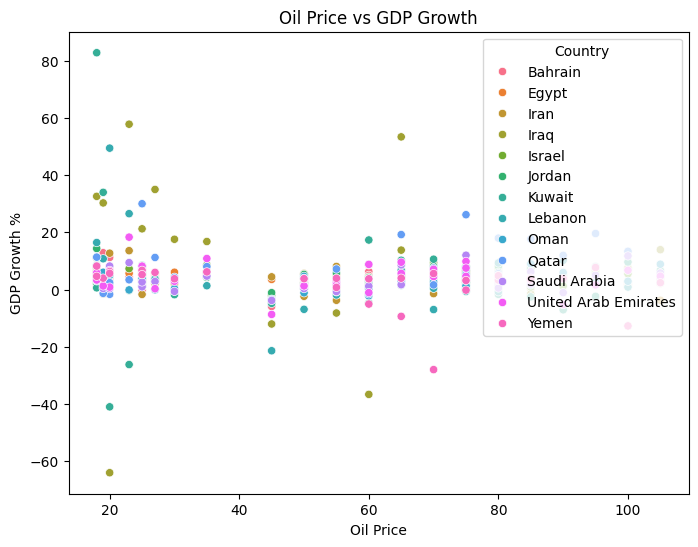

In [9]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Brent_Oil_Price_USD_per_barrel",
    y="GDP_growth_annual_pct",
    hue="Country",
    data=df
)

plt.title("Oil Price vs GDP Growth")
plt.xlabel("Oil Price")
plt.ylabel("GDP Growth %")

plt.show()


## Correlation Analysis

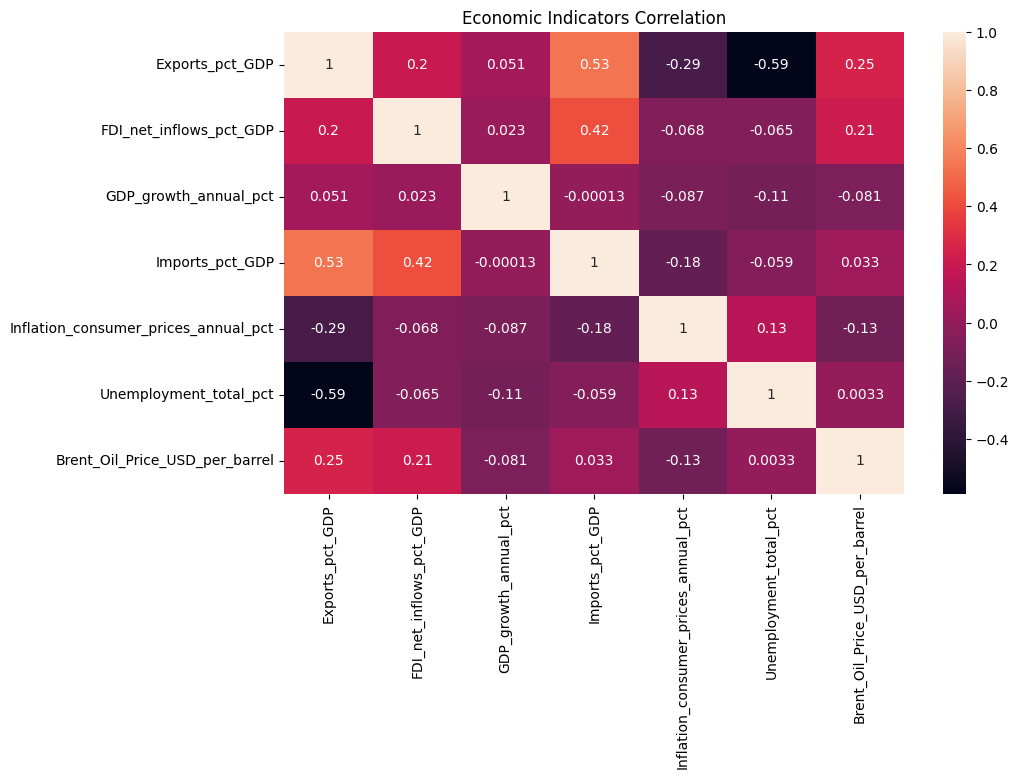

In [10]:
corr = df[
[
"Exports_pct_GDP",
"FDI_net_inflows_pct_GDP",
"GDP_growth_annual_pct",
"Imports_pct_GDP",
"Inflation_consumer_prices_annual_pct",
"Unemployment_total_pct",
"Brent_Oil_Price_USD_per_barrel"
]
].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)

plt.title("Economic Indicators Correlation")

plt.show()

## Country GDP Trend

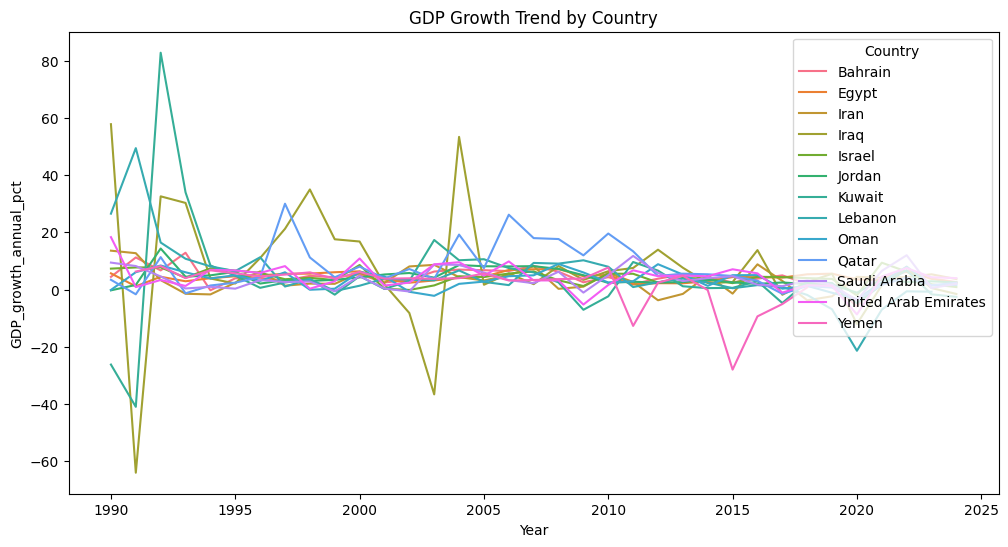

In [11]:

plt.figure(figsize=(12,6))

sns.lineplot(
    x="Year",
    y="GDP_growth_annual_pct",
    hue="Country",
    data=df
)

plt.title("GDP Growth Trend by Country")

plt.show()


## Oil Price Impact on Exports

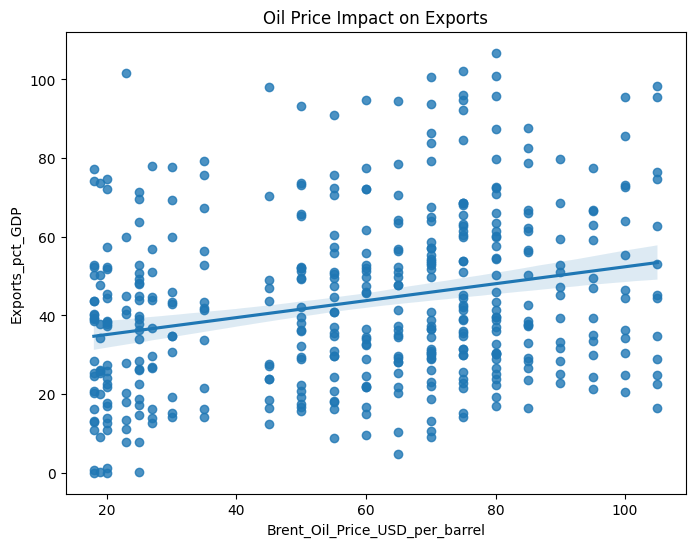

In [12]:
plt.figure(figsize=(8,6))

sns.regplot(
    x="Brent_Oil_Price_USD_per_barrel",
    y="Exports_pct_GDP",
    data=df
)

plt.title("Oil Price Impact on Exports")

plt.show()

## Inflation → Inflation_consumer_prices_annual_pct

## Unemployment → Unemployment_total_pct

## GDP Growth → GDP_growth_annual_pct

## Brent Oil Price → Brent_Oil_Price_USD_per_barrel

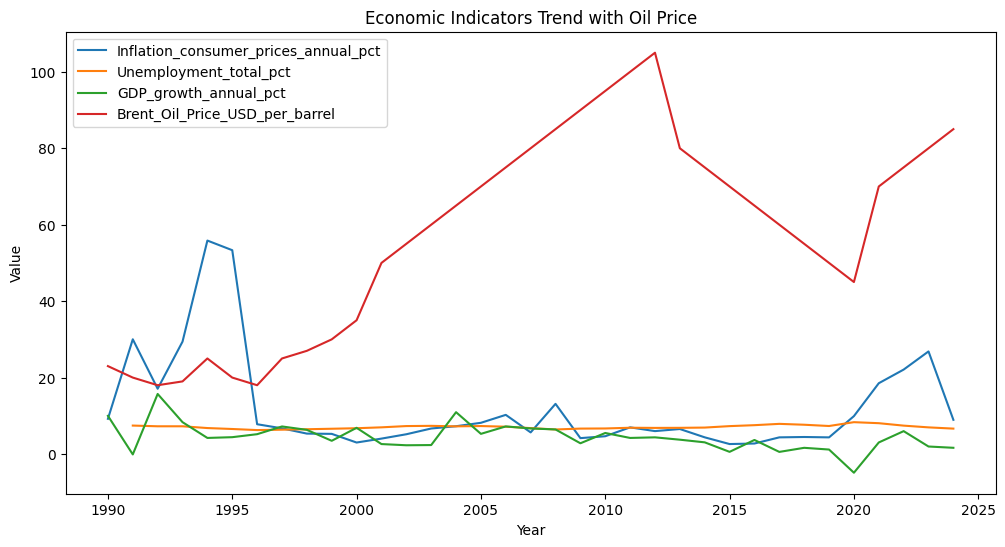

In [13]:
yearly = df.groupby("Year")[[
"Inflation_consumer_prices_annual_pct",
"Unemployment_total_pct",
"GDP_growth_annual_pct",
"Brent_Oil_Price_USD_per_barrel"
]].mean()

yearly.plot(figsize=(12,6))

plt.title("Economic Indicators Trend with Oil Price")
plt.xlabel("Year")
plt.ylabel("Value")

plt.show()

## Brent Oil Price

##  Inflation

## Unemployment

## GDP Growth

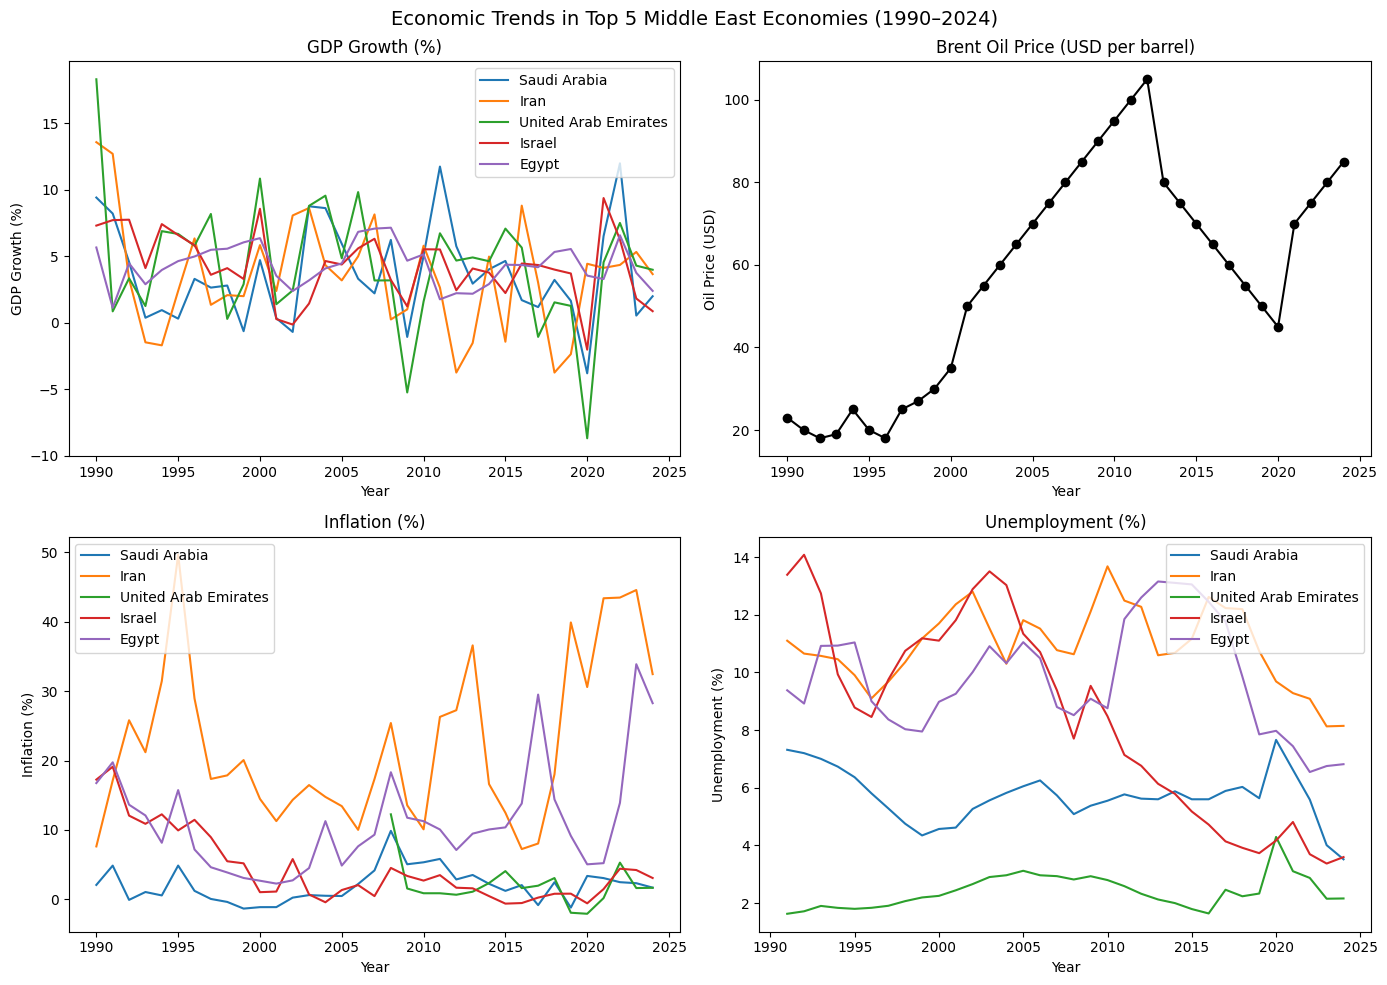

In [14]:
# Top 5 countries
countries = ["Saudi Arabia","Iran","United Arab Emirates","Israel","Egypt"]

df = df[df["Country"].isin(countries)]

# Create subplot layout
fig, axes = plt.subplots(2,2, figsize=(14,10))

# -------------------------
# GDP Growth
# -------------------------
for c in countries:
    temp = df[df["Country"]==c]
    axes[0,0].plot(temp["Year"], temp["GDP_growth_annual_pct"], label=c)

axes[0,0].set_title("GDP Growth (%)")
axes[0,0].set_xlabel("Year")
axes[0,0].set_ylabel("GDP Growth (%)")
axes[0,0].legend()

# -------------------------
# Brent Oil Price
# -------------------------
oil_year = df.groupby("Year")["Brent_Oil_Price_USD_per_barrel"].mean()

axes[0,1].plot(oil_year.index, oil_year.values, color="black", marker="o")

axes[0,1].set_title("Brent Oil Price (USD per barrel)")
axes[0,1].set_xlabel("Year")
axes[0,1].set_ylabel("Oil Price (USD)")

# -------------------------
# Inflation
# -------------------------
for c in countries:
    temp = df[df["Country"]==c]
    axes[1,0].plot(temp["Year"], temp["Inflation_consumer_prices_annual_pct"], label=c)

axes[1,0].set_title("Inflation (%)")
axes[1,0].set_xlabel("Year")
axes[1,0].set_ylabel("Inflation (%)")
axes[1,0].legend()

# -------------------------
# Unemployment
# -------------------------
for c in countries:
    temp = df[df["Country"]==c]
    axes[1,1].plot(temp["Year"], temp["Unemployment_total_pct"], label=c)

axes[1,1].set_title("Unemployment (%)")
axes[1,1].set_xlabel("Year")
axes[1,1].set_ylabel("Unemployment (%)")
axes[1,1].legend()

# Main title
plt.suptitle("Economic Trends in Top 5 Middle East Economies (1990–2024)", fontsize=14)

plt.tight_layout()

plt.show()

## Correlation Heatmap

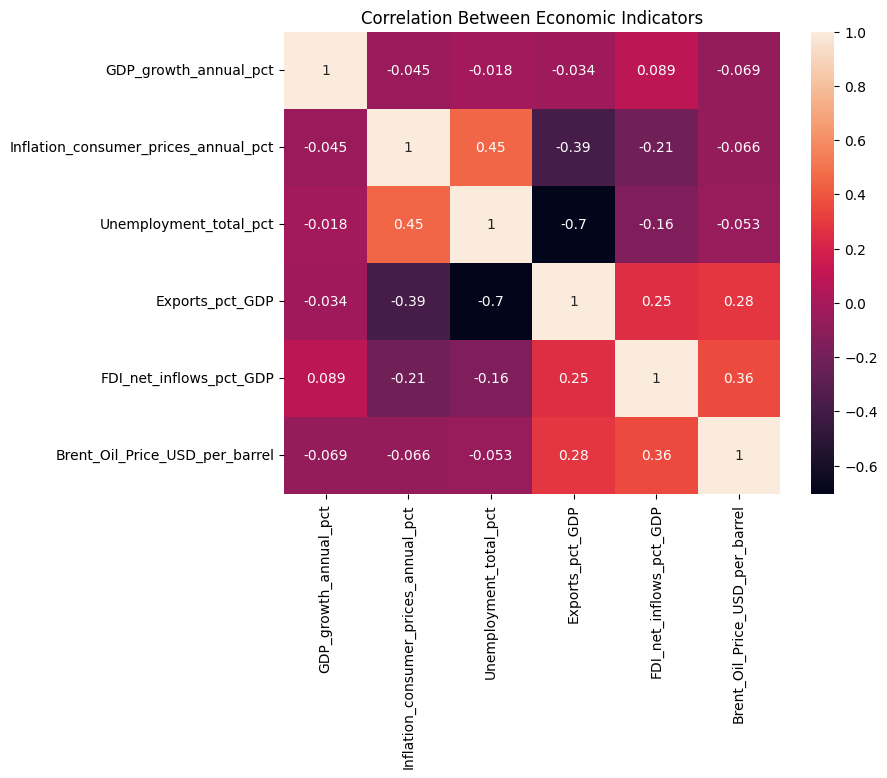

In [15]:
cols = [
"GDP_growth_annual_pct",
"Inflation_consumer_prices_annual_pct",
"Unemployment_total_pct",
"Exports_pct_GDP",
"FDI_net_inflows_pct_GDP",
"Brent_Oil_Price_USD_per_barrel"
]

corr = df[cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)

plt.title("Correlation Between Economic Indicators")
plt.show()

## Oil Price vs GDP Growth (Impact Analysis)

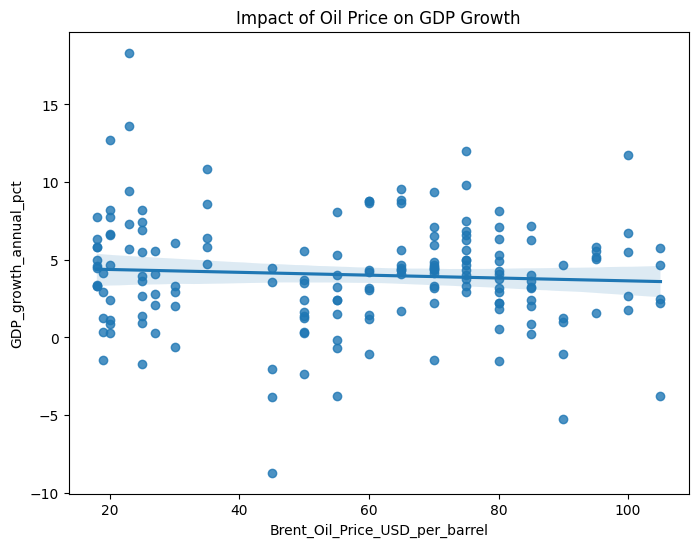

In [16]:
plt.figure(figsize=(8,6))

sns.regplot(
x="Brent_Oil_Price_USD_per_barrel",
y="GDP_growth_annual_pct",
data=df
)

plt.title("Impact of Oil Price on GDP Growth")
plt.show()

## GDP per Capita Trend

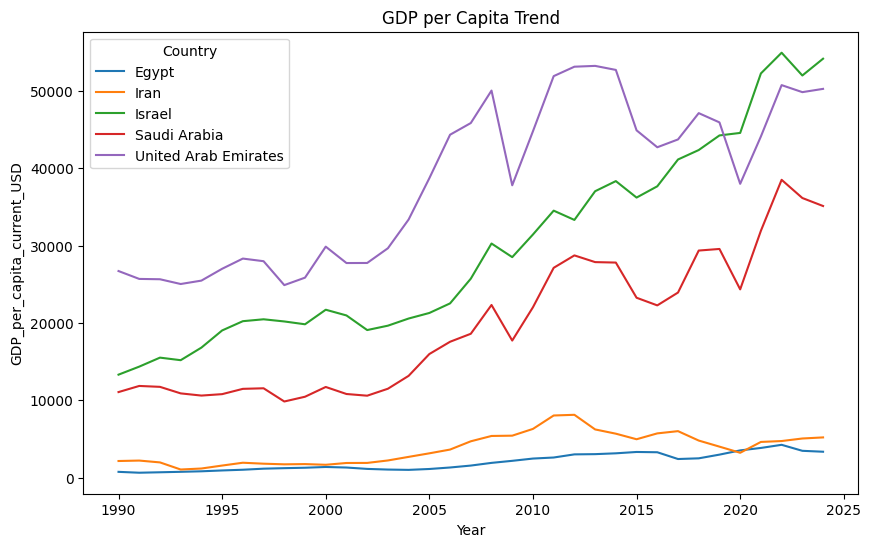

In [17]:
plt.figure(figsize=(10,6))

sns.lineplot(
x="Year",
y="GDP_per_capita_current_USD",
hue="Country",
data=df
)

plt.title("GDP per Capita Trend")
plt.show()

## Exports vs Oil Price

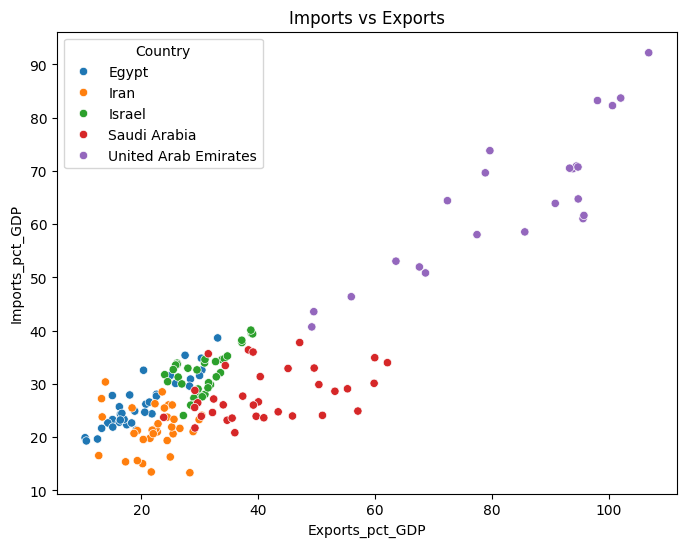

In [18]:
plt.figure(figsize=(8,6))

sns.scatterplot(
x="Exports_pct_GDP",
y="Imports_pct_GDP",
hue="Country",
data=df
)

plt.title("Imports vs Exports")
plt.show()

## Oil Price Distribution

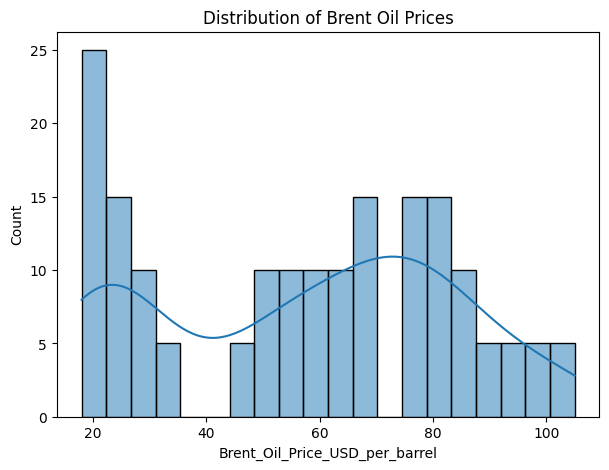

In [19]:
plt.figure(figsize=(7,5))

sns.histplot(
df["Brent_Oil_Price_USD_per_barrel"],
bins=20,
kde=True
)

plt.title("Distribution of Brent Oil Prices")
plt.show()

## Unemployment vs GDP Growth

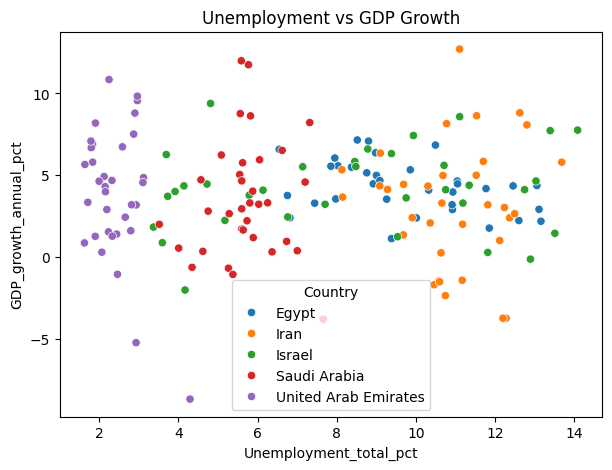

In [20]:
plt.figure(figsize=(7,5))

sns.scatterplot(
x="Unemployment_total_pct",
y="GDP_growth_annual_pct",
hue="Country",
data=df
)

plt.title("Unemployment vs GDP Growth")
plt.show()

## Boxplot (Country Comparison)

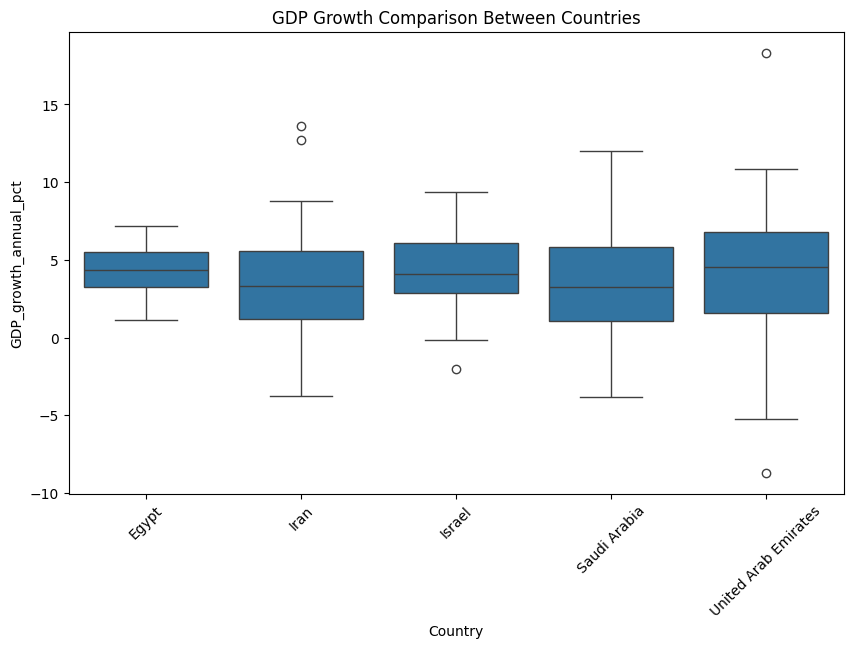

In [21]:
plt.figure(figsize=(10,6))

sns.boxplot(
x="Country",
y="GDP_growth_annual_pct",
data=df
)

plt.title("GDP Growth Comparison Between Countries")
plt.xticks(rotation=45)

plt.show()

---
# Conclusion

The analysis of the **Middle East Economy & Oil Prices (1990–2024)** provides several important insights:

1. **Oil Price Trends:**  
   - Brent oil prices have shown significant fluctuations over the past three decades, peaking around 2010–2012 and dipping during global crises such as the 2008 financial crisis and the COVID-19 pandemic.  
   - These fluctuations have a direct impact on the economies of oil-exporting countries in the region.

2. **GDP Growth Patterns:**  
   - GDP growth in the top 5 Middle East economies (Saudi Arabia, Iran, United Arab Emirates, Israel, Egypt) shows a strong correlation with oil price trends.  
   - Countries with higher dependency on oil exports exhibit more volatile GDP growth during periods of oil price fluctuation.

3. **Inflation and Unemployment:**  
   - Inflation tends to rise during periods of high oil prices in oil-importing countries and falls when prices drop.  
   - Unemployment trends vary across countries, but overall, oil-dependent economies show a stronger connection between oil price shocks and labor market performance.

4. **Trade and Investment Indicators:**  
   - Exports as a percentage of GDP are positively correlated with oil prices, highlighting the region’s dependence on oil revenue.  
   - Foreign Direct Investment inflows (% of GDP) are influenced by economic stability, which is indirectly affected by oil price volatility.

5. **Economic Diversification:**  
   - Some countries, such as the United Arab Emirates and Saudi Arabia, are gradually diversifying their economies to reduce dependence on oil.  
   - Non-oil sectors like tourism, technology, and finance are contributing to GDP, which helps stabilize growth during periods of low oil prices.

6. **Key Insights:**  
   - Oil price is a major driver of economic performance in the Middle East, affecting GDP growth, inflation, unemployment, and trade.  
   - Countries with diversified economies are better able to withstand oil price shocks.  
   - Policymakers can use these insights to plan economic reforms, stabilize growth, and manage fiscal budgets more effectively.

---

**Overall**, the Middle East economies remain highly sensitive to global oil price changes, but diversification efforts and strategic investments in non-oil sectors are crucial for long-term economic stability and sustainable growth.